In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnv2_preprocess
from sklearn.metrics import classification_report, confusion_matrix

print(f"TF version: {tf.__version__}")
print(f"GPU devices: {tf.config.list_physical_devices('GPU')}")
tf.random.set_seed(42)
np.random.seed(42)

2026-05-17 14:02:55.871059: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779026576.076592      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779026576.134591      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779026576.567466      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779026576.567517      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779026576.567521      23 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
DATA_ROOT = Path("/kaggle/input/datasets/candenizaytekin/crackdataset-v1")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR   = DATA_ROOT / "val"
TUNE_DIR  = DATA_ROOT / "tune"
LOCK_DIR  = DATA_ROOT / "lock"

CLASSES = ["cross", "longitudinal", "no_crack", "transverse"]  # alphabetical
NUM_CLASSES = 4
BATCH_SIZE = 64

# Türkçe -> İngilizce eşleme (manuel set için)
TR_MAP = {"çapraz": "cross", "dikey": "longitudinal", "yatay": "transverse"}

# Veri kontrolü
for d in [TRAIN_DIR, VAL_DIR, TUNE_DIR, LOCK_DIR]:
    if d.exists():
        sub = [p.name for p in d.iterdir() if p.is_dir()]
        print(f"{d.name}/: {sub}")
    else:
        print(f"MISSING: {d}")

train/: ['no_crack', 'longitudinal', 'cross', 'transverse']
val/: ['no_crack', 'longitudinal', 'cross', 'transverse']
tune/: ['�apraz', 'dikey', 'yatay']
lock/: ['�apraz', 'dikey', 'yatay']


In [3]:
class_counts = {c: len(list((TRAIN_DIR / c).glob("*"))) for c in CLASSES}
total = sum(class_counts.values())
class_weights = {i: total / (NUM_CLASSES * cnt) for i, (c, cnt) in enumerate(class_counts.items())}
print("Train counts:", class_counts)
print("Class weights:", {CLASSES[i]: round(w, 3) for i, w in class_weights.items()})

Train counts: {'cross': 6956, 'longitudinal': 8000, 'no_crack': 17000, 'transverse': 7484}
Class weights: {'cross': 1.417, 'longitudinal': 1.232, 'no_crack': 0.58, 'transverse': 1.317}


In [4]:
IMG_SIZE_CNN = 128

train_cnn = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=(IMG_SIZE_CNN, IMG_SIZE_CNN),
    batch_size=BATCH_SIZE, class_names=CLASSES,
    label_mode="categorical", shuffle=True, seed=42
)
val_cnn = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=(IMG_SIZE_CNN, IMG_SIZE_CNN),
    batch_size=BATCH_SIZE, class_names=CLASSES,
    label_mode="categorical", shuffle=False
)

norm = layers.Rescaling(1./255)
train_cnn = train_cnn.map(lambda x, y: (norm(x), y)).prefetch(tf.data.AUTOTUNE)
val_cnn   = val_cnn.map(lambda x, y: (norm(x), y)).prefetch(tf.data.AUTOTUNE)

Found 39440 files belonging to 4 classes.


I0000 00:00:1779026638.158587      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 5900 files belonging to 4 classes.


In [5]:
def build_custom_cnn():
    inp = layers.Input(shape=(IMG_SIZE_CNN, IMG_SIZE_CNN, 3))
    x = inp
    for f in [32, 64, 128, 256]:
        x = layers.Conv2D(f, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(2)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return models.Model(inp, out, name="custom_cnn")

cnn = build_custom_cnn()
cnn.compile(optimizer=optimizers.Adam(1e-3),
            loss="categorical_crossentropy", metrics=["accuracy"])
cnn.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,156 (1.74 MB)

 Trainable params: 456,196 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [6]:
cnn_cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    callbacks.ModelCheckpoint("/kaggle/working/best_cnn.keras",
                              monitor="val_accuracy", save_best_only=True)
]

hist_cnn = cnn.fit(train_cnn, validation_data=val_cnn,
                   epochs=30, class_weight=class_weights, callbacks=cnn_cb)

Epoch 1/30


I0000 00:00:1779026650.596875      75 service.cc:152] XLA service 0x7b82b0017a20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779026650.596923      75 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779026651.576621      75 cuda_dnn.cc:529] Loaded cuDNN version 91002


  7/617 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - accuracy: 0.4392 - loss: 1.5154

I0000 00:00:1779026657.397536      75 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


617/617 ━━━━━━━━━━━━━━━━━━━━ 53s 70ms/step - accuracy: 0.8518 - loss: 0.4572 - val_accuracy: 0.1825 - val_loss: 2.7888 - learning_rate: 0.0010
Epoch 2/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.9258 - loss: 0.2387 - val_accuracy: 0.8929 - val_loss: 0.2297 - learning_rate: 0.0010
Epoch 3/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.9319 - loss: 0.2159 - val_accuracy: 0.1029 - val_loss: 5.3037 - learning_rate: 0.0010
Epoch 4/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.9385 - loss: 0.1969 - val_accuracy: 0.3749 - val_loss: 2.5647 - learning_rate: 0.0010
Epoch 5/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.9384 - loss: 0.1921 - val_accuracy: 0.9125 - val_loss: 0.2239 - learning_rate: 0.0010
Epoch 6/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.9426 - loss: 0.1791 - val_accuracy: 0.6027 - val_loss: 1.0870 - learning_rate: 0.0010
Epoch 7/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.9474 - loss: 0.1694

In [7]:
IMG_SIZE_MN = 224
BATCH_SIZE_MN = 32  # 224x224 için 64 yerine 32, RAM/GPU güvenliği

def make_mn_ds(directory, shuffle):
    ds = tf.keras.utils.image_dataset_from_directory(
        directory, image_size=(IMG_SIZE_MN, IMG_SIZE_MN),
        batch_size=BATCH_SIZE_MN, class_names=CLASSES,
        label_mode="categorical", shuffle=shuffle,
        seed=42 if shuffle else None
    )
    return ds.map(lambda x, y: (mnv2_preprocess(x), y)).prefetch(tf.data.AUTOTUNE)

train_mn = make_mn_ds(TRAIN_DIR, True)
val_mn   = make_mn_ds(VAL_DIR, False)

Found 39440 files belonging to 4 classes.
Found 5900 files belonging to 4 classes.


In [8]:
base = MobileNetV2(input_shape=(IMG_SIZE_MN, IMG_SIZE_MN, 3),
                   include_top=False, weights="imagenet")
base.trainable = False

mn = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")
])
mn.compile(optimizer=optimizers.Adam(1e-3),
           loss="categorical_crossentropy", metrics=["accuracy"])

hist_mn_p1 = mn.fit(train_mn, validation_data=val_mn,
                    epochs=8, class_weight=class_weights,
                    callbacks=[callbacks.EarlyStopping(monitor="val_loss",
                               patience=4, restore_best_weights=True)])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 60s 39ms/step - accuracy: 0.8361 - loss: 0.4823 - val_accuracy: 0.9222 - val_loss: 0.1880
Epoch 2/8
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.9058 - loss: 0.2950 - val_accuracy: 0.9100 - val_loss: 0.2012
Epoch 3/8
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.9129 - loss: 0.2814 - val_accuracy: 0.9147 - val_loss: 0.1958
Epoch 4/8
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.9099 - loss: 0.2843 - val_accuracy: 0.9227 - val_loss: 0.1859
Epoch 5/8
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.9125 - loss: 0.2780 - val_accuracy: 0.9190 - val_loss: 0.1956
Epoch 6/8
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.9129 - loss: 0.2726 - val_accuracy: 0.9178 - val_loss: 0.1987
Epoch 7/8
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - accuracy: 0.9128 - loss: 0.2764 - val_accuracy: 0.9192 - val_loss: 0.1882
Epoch 8/8
1233/1233 ━━━━━━━━━━━━━━

In [9]:
base.trainable = True
for l in base.layers[:100]:
    l.trainable = False

mn.compile(optimizer=optimizers.Adam(1e-5),
           loss="categorical_crossentropy", metrics=["accuracy"])

hist_mn_p2 = mn.fit(train_mn, validation_data=val_mn,
                    epochs=10, class_weight=class_weights,
                    callbacks=[
                        callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
                        callbacks.ModelCheckpoint("/kaggle/working/best_mn.keras",
                                                  monitor="val_accuracy", save_best_only=True)
                    ])

Epoch 1/10


2026-05-17 14:18:03.762633: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-17 14:18:03.959901: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1231/1233 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8555 - loss: 0.4870

2026-05-17 14:18:53.251718: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-17 14:18:53.447741: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1233/1233 ━━━━━━━━━━━━━━━━━━━━ 84s 50ms/step - accuracy: 0.8556 - loss: 0.4867 - val_accuracy: 0.9105 - val_loss: 0.2426
Epoch 2/10
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 44s 36ms/step - accuracy: 0.9233 - loss: 0.2528 - val_accuracy: 0.9288 - val_loss: 0.1816
Epoch 3/10
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 44s 36ms/step - accuracy: 0.9391 - loss: 0.1952 - val_accuracy: 0.9431 - val_loss: 0.1441
Epoch 4/10
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.9511 - loss: 0.1585 - val_accuracy: 0.9429 - val_loss: 0.1458
Epoch 5/10
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 44s 36ms/step - accuracy: 0.9581 - loss: 0.1361 - val_accuracy: 0.9488 - val_loss: 0.1311
Epoch 6/10
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 44s 36ms/step - accuracy: 0.9689 - loss: 0.1040 - val_accuracy: 0.9475 - val_loss: 0.1352
Epoch 7/10
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 44s 36ms/step - accuracy: 0.9752 - loss: 0.0865 - val_accuracy: 0.9493 - val_loss: 0.1305
Epoch 8/10
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.9803 - loss: 0.06

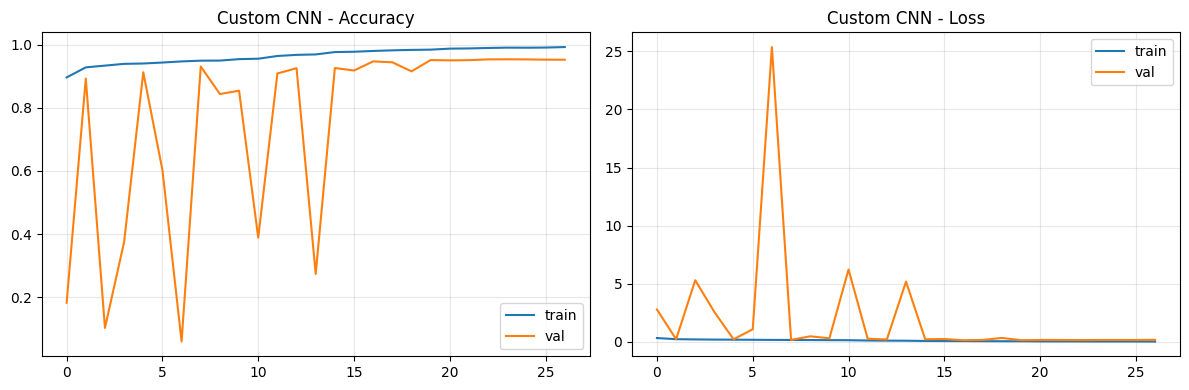

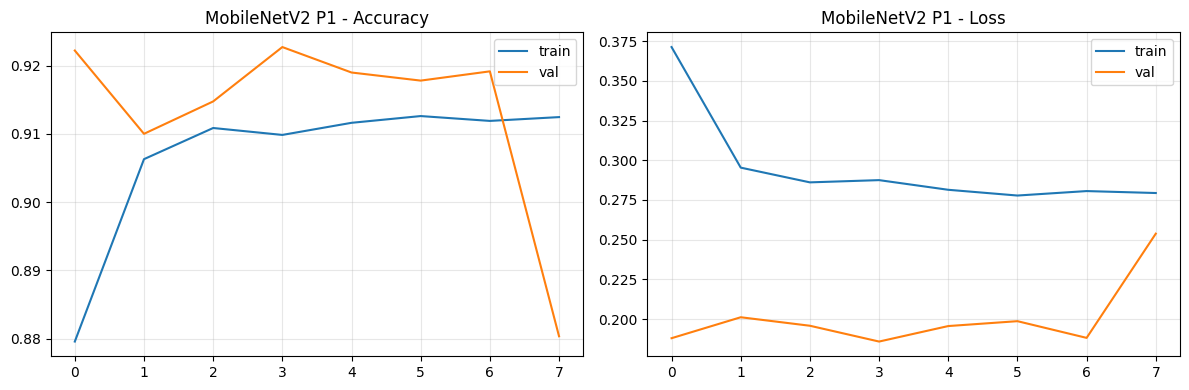

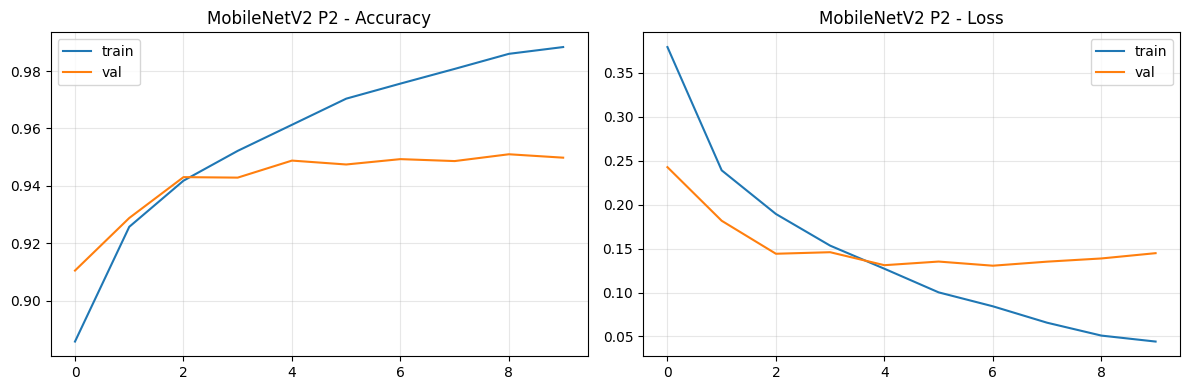

In [10]:
def plot_hist(h, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h.history["accuracy"], label="train")
    ax[0].plot(h.history["val_accuracy"], label="val")
    ax[0].set_title(f"{title} - Accuracy"); ax[0].legend(); ax[0].grid(alpha=0.3)
    ax[1].plot(h.history["loss"], label="train")
    ax[1].plot(h.history["val_loss"], label="val")
    ax[1].set_title(f"{title} - Loss"); ax[1].legend(); ax[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/curves_{title.replace(' ', '_').lower()}.png", dpi=150)
    plt.show()

plot_hist(hist_cnn, "Custom CNN")
plot_hist(hist_mn_p1, "MobileNetV2 P1")
plot_hist(hist_mn_p2, "MobileNetV2 P2")

In [11]:
def load_manual_set(root_dir, img_size):
    """Türkçe klasörlerden yükle, İngilizce sınıf indeksine eşle."""
    images, labels = [], []
    class_to_idx = {c: i for i, c in enumerate(CLASSES)}
    for tr_name, eng_name in TR_MAP.items():
        folder = root_dir / tr_name
        for p in folder.glob("*"):
            img = cv2.imread(str(p))
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(class_to_idx[eng_name])
    return np.array(images), np.array(labels)

# Lock seti (final paper number)
X_lock_cnn, y_lock = load_manual_set(LOCK_DIR, IMG_SIZE_CNN)
X_lock_mn, _      = load_manual_set(LOCK_DIR, IMG_SIZE_MN)

# Tune + Lock kombine (daha büyük örneklem için)
X_tune_cnn, y_tune = load_manual_set(TUNE_DIR, IMG_SIZE_CNN)
X_tune_mn, _      = load_manual_set(TUNE_DIR, IMG_SIZE_MN)
X_all_cnn = np.concatenate([X_tune_cnn, X_lock_cnn])
X_all_mn  = np.concatenate([X_tune_mn, X_lock_mn])
y_all     = np.concatenate([y_tune, y_lock])

print(f"Lock: {len(y_lock)} images, distribution: {np.bincount(y_lock, minlength=NUM_CLASSES)}")
print(f"All manual (tune+lock): {len(y_all)} images")

Lock: 98 images, distribution: [ 0 39  0 59]
All manual (tune+lock): 260 images


In [12]:
def evaluate_model(model, X, y, name, preprocess="rescale"):
    if preprocess == "rescale":
        X_proc = X.astype(np.float32) / 255.0
    else:  # mobilenetv2
        X_proc = mnv2_preprocess(X.astype(np.float32))
    preds = model.predict(X_proc, verbose=0).argmax(axis=1)
    acc = (preds == y).mean()
    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f} ({(preds == y).sum()}/{len(y)})")
    manual_classes = ["cross", "longitudinal", "transverse"]
    manual_idx = [CLASSES.index(c) for c in manual_classes]
    print(classification_report(y, preds, labels=manual_idx,
                                target_names=manual_classes, zero_division=0))
    return preds, acc

print("=" * 60)
print("LOCK SET (150 manuel etiketli)")
print("=" * 60)
preds_cnn_lock, acc_cnn_lock = evaluate_model(cnn, X_lock_cnn, y_lock, "Custom CNN", "rescale")
preds_mn_lock,  acc_mn_lock  = evaluate_model(mn,  X_lock_mn,  y_lock, "MobileNetV2", "mnv2")

print("=" * 60)
print("FULL MANUAL (400 = tune + lock)")
print("=" * 60)
preds_cnn_all, acc_cnn_all = evaluate_model(cnn, X_all_cnn, y_all, "Custom CNN", "rescale")
preds_mn_all,  acc_mn_all  = evaluate_model(mn,  X_all_mn,  y_all, "MobileNetV2", "mnv2")

LOCK SET (150 manuel etiketli)

=== Custom CNN ===
Accuracy: 0.7347 (72/98)
              precision    recall  f1-score   support

       cross       0.00      0.00      0.00         0
longitudinal       1.00      0.46      0.63        39
  transverse       0.93      0.92      0.92        59

   micro avg       0.74      0.73      0.74        98
   macro avg       0.64      0.46      0.52        98
weighted avg       0.96      0.73      0.81        98


=== MobileNetV2 ===
Accuracy: 0.7551 (74/98)
              precision    recall  f1-score   support

       cross       0.00      0.00      0.00         0
longitudinal       1.00      0.49      0.66        39
  transverse       0.93      0.93      0.93        59

    accuracy                           0.76        98
   macro avg       0.64      0.47      0.53        98
weighted avg       0.96      0.76      0.82        98

FULL MANUAL (400 = tune + lock)

=== Custom CNN ===
Accuracy: 0.7692 (200/260)
              precision    recall  f1

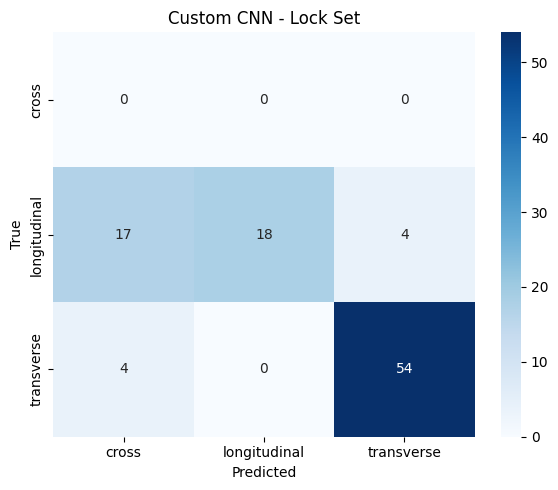

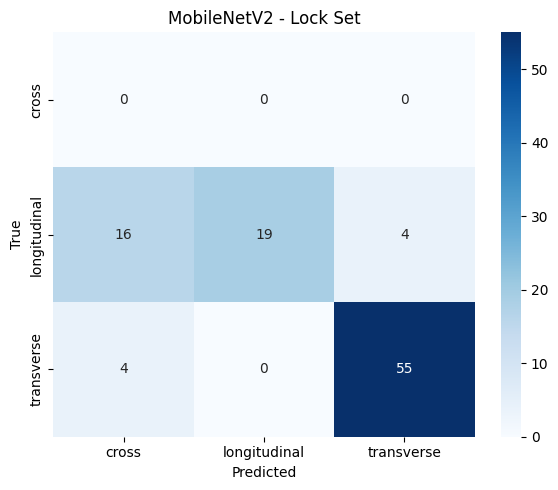

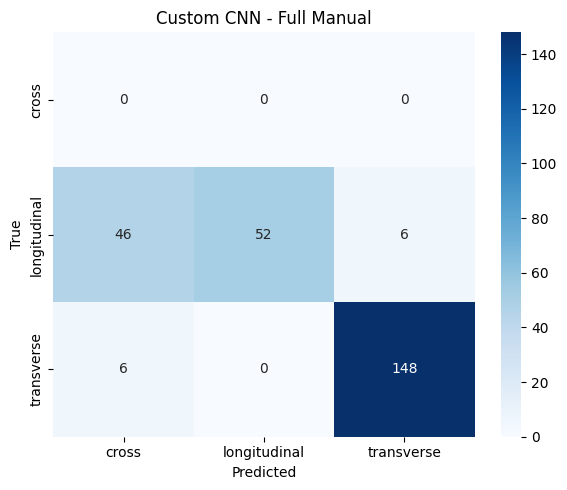

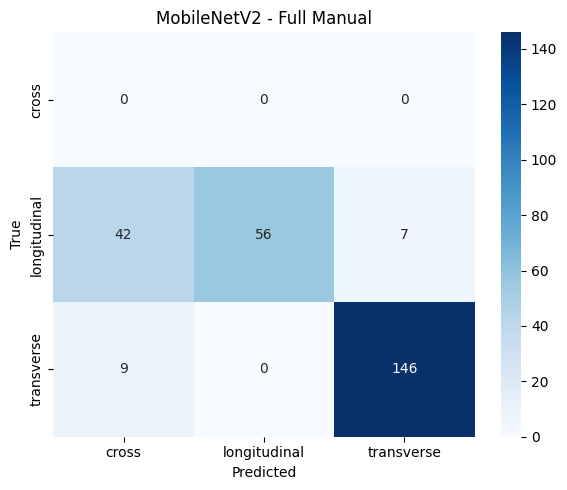

In [13]:
def plot_cm(y_true, y_pred, title, fname):
    labels_show = ["cross", "longitudinal", "transverse"]
    idx = [CLASSES.index(c) for c in labels_show]
    cm = confusion_matrix(y_true, y_pred, labels=idx)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_show, yticklabels=labels_show, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{fname}.png", dpi=150)
    plt.show()

plot_cm(y_lock, preds_cnn_lock, "Custom CNN - Lock Set",     "cm_cnn_lock")
plot_cm(y_lock, preds_mn_lock,  "MobileNetV2 - Lock Set",    "cm_mn_lock")
plot_cm(y_all,  preds_cnn_all,  "Custom CNN - Full Manual",  "cm_cnn_all")
plot_cm(y_all,  preds_mn_all,   "MobileNetV2 - Full Manual", "cm_mn_all")

In [14]:
val_cnn_acc = cnn.evaluate(val_cnn, verbose=0)[1]
val_mn_acc  = mn.evaluate(val_mn, verbose=0)[1]

summary = pd.DataFrame({
    "Model": ["Hough V1 (baseline)", "Custom CNN (128)", "MobileNetV2 (224)"],
    "Val (Hough)": [None, val_cnn_acc, val_mn_acc],
    "Lock 150 (Manual)": [0.68, acc_cnn_lock, acc_mn_lock],
    "Full 400 (Manual)": [0.725, acc_cnn_all, acc_mn_all]
})
print(summary.to_string(index=False))
summary.to_csv("/kaggle/working/comparison.csv", index=False)

              Model  Val (Hough)  Lock 150 (Manual)  Full 400 (Manual)
Hough V1 (baseline)          NaN           0.680000           0.725000
   Custom CNN (128)     0.946949           0.734694           0.769231
  MobileNetV2 (224)     0.949322           0.755102           0.776923
